In [414]:

# ==============================
# Imports & Settings
# ==============================

# Data manipulation
import pandas as pd
import numpy as np
import time  # ✅ Execution time için

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone  # ✅ For cloning pipelines in ablation study
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, 
    RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,  # ✅ PR-AUC için
    PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # ✅ Pipeline için
from xgboost import XGBClassifier

# Statistical analysis
from scipy.stats import chi2_contingency  # ✅ Cramér's V için

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Imports loaded, settings configured.")

# ==============================
# Methodology Notes
# ==============================
# - Class imbalance handling methods:
#   * Logistic Regression: SMOTE (required for linear models)
#   * XGBoost + SMOTE: SMOTE oversampling (applied inside imblearn Pipeline)
#   * XGBoost + scale_pos_weight: Class weighting (preferred for tree models)
# - SMOTE is applied inside imblearn Pipeline
# - SMOTE is applied ONLY on training data (train split or CV folds)
# - scale_pos_weight is computed from y_train ONLY (no data leakage)
# - class_weight="balanced" is NOT used (using scale_pos_weight for XGBoost instead)
# - Train/test split is stratified and reproducible (random_state=42)
# - Scaling is fitted only on training data and applied to test data
# - Tree-based models (XGBoost) do NOT require scaling


✅ Imports loaded, settings configured.


In [416]:
# Load / info
# ==============================

# Load dataset
data = pd.read_csv("Telco-Customer-Churn.csv")

print(f"Initial dataset shape: {data.shape}")
display(data.head(10))

print("\nColumn dtypes:")
print(data.dtypes)


print("\nChurn distribution:")
print(data["Churn"].value_counts())
print("\nChurn distribution (%):")
print(data["Churn"].value_counts(normalize=True) * 100)

# ============================================
# Show unique values for each column
# ============================================

for col in data.columns:
    print(f"\n=== {col} ===")
    
   
    if data[col].dtype == 'object':
        print(data[col].unique())
    
    else:
        print(f"Min: {data[col].min()}, Max: {data[col].max()}, Unique count: {data[col].nunique()}")



Initial dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



Column dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn distribution (%):
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

=== customerID ===
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

=== gender ===
['Female' 'Male']

=== SeniorCitizen ===
Min: 0, Max: 1, Unique count: 2

=== Partner 

In [418]:
# ============================================
# Professional Data Cleaning – Telco Churn
# ============================================

print(f"Starting cleaning pipeline. Initial shape: {data.shape}")

# Object kolonları belirleyelim
obj_cols = data.select_dtypes(include=["object"]).columns.tolist()
print("\n[Info] Object columns detected:")
print(obj_cols)


Starting cleaning pipeline. Initial shape: (7043, 21)

[Info] Object columns detected:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [420]:
print("\n[Step 1] Replacing blank / whitespace-only strings in object columns with NaN...")

# Her obje kolonunda kaç tane "boş / sadece whitespace" var?
blank_counts_before = {
    col: (data[col].astype(str).str.strip() == "").sum()
    for col in obj_cols
}

print("\nBlank value counts BEFORE replacement:")
for col, cnt in blank_counts_before.items():
    if cnt > 0:
        print(f"  {col}: {cnt}")

# Boş ya da sadece boşluk içeren stringleri NaN yap
data[obj_cols] = data[obj_cols].replace(r"^\s*$", np.nan, regex=True)

print("\nMissing values per column AFTER blank → NaN replacement:")
print(data.isnull().sum())



[Step 1] Replacing blank / whitespace-only strings in object columns with NaN...

Blank value counts BEFORE replacement:
  TotalCharges: 11

Missing values per column AFTER blank → NaN replacement:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [422]:
#totalcharges null olanların tüm özellikleri nedir?
#tenure 0 olur çünkü aboneliğin ilk ayı henüz fatura oluşmamış 

missing_totcharges = data[data["TotalCharges"].isnull()]
print(missing_totcharges .shape)
display(missing_totcharges .head())


(11, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No


In [424]:
print("\n[Step 2] Converting TotalCharges to numeric (invalid values → NaN)...")

print("Dtype BEFORE:", data["TotalCharges"].dtype)

# TotalCharges kolonunu sayıya çevir, hatalı değerler NaN olsun
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

print("Dtype AFTER:", data["TotalCharges"].dtype)

print("\nMissing values per column AFTER conversion:")
print(data.isnull().sum())



[Step 2] Converting TotalCharges to numeric (invalid values → NaN)...
Dtype BEFORE: object
Dtype AFTER: float64

Missing values per column AFTER conversion:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [426]:
print("\n[Step 3] Dropping rows with missing TotalCharges...")
print("Note: TotalCharges NaN occurs for new customers (tenure=0) with no billing history yet.")
print("These 11 rows are dropped as they represent <0.2% of the dataset.")

before_rows = data.shape[0]

# Yalnızca TotalCharges NaN satırlarını sil
data = data.dropna(subset=["TotalCharges"])

after_rows = data.shape[0]

print(f"Rows before dropping: {before_rows}")
print(f"Rows after  dropping: {after_rows}")
print(f"Rows dropped (TotalCharges NaN): {before_rows - after_rows}")




[Step 3] Dropping rows with missing TotalCharges...
Note: TotalCharges NaN occurs for new customers (tenure=0) with no billing history yet.
These 11 rows are dropped as they represent <0.2% of the dataset.
Rows before dropping: 7043
Rows after  dropping: 7032
Rows dropped (TotalCharges NaN): 11


In [428]:
print("\n[Step 4] Checking remaining NaN values after cleaning...")

remaining_na = data.isnull().sum()
print(remaining_na)

if remaining_na.sum() == 0:
    print("\n✅ No remaining missing values. Dataset is clean.")
else:
    print("\n⚠️ Some missing values remain. Additional cleaning may be required.")



[Step 4] Checking remaining NaN values after cleaning...
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

✅ No remaining missing values. Dataset is clean.


In [430]:
# 5) Duplicate satırları kontrol et ve varsa sil
print("\n[Step 5] Checking for duplicate rows...")

n_duplicates = data.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates}")

if n_duplicates > 0:
    print("Dropping duplicate rows...")
    before_dup = data.shape[0]
    data = data.drop_duplicates()
    after_dup = data.shape[0]
    print(f"Rows before dropping duplicates: {before_dup}")
    print(f"Rows after  dropping duplicates: {after_dup}")
    print(f"Duplicates dropped: {before_dup - after_dup}")
else:
    print("No duplicate rows found.")


[Step 5] Checking for duplicate rows...
Duplicate rows found: 0
No duplicate rows found.


In [432]:
# ============================================
# Replace "No internet service" / "No phone service" with "No"
# ============================================

internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# Internet services
for col in internet_dependent_cols:
    data[col] = data[col].replace("No internet service", "No")

# Phone service
data["MultipleLines"] = data["MultipleLines"].replace("No phone service", "No")

print("Dönüşüm tamamlandı. Yeni benzersiz değerler:")
for col in internet_dependent_cols + ["MultipleLines"]:
    print(f"{col}: {data[col].unique()}")

# ============================================
# Separate categorical & numerical columns and print unique values
# ============================================

cat_cols = data.select_dtypes(include=['object']).columns
num_cols = data.select_dtypes(exclude=['object']).columns

print("\n===== Categorical Features =====")
for col in cat_cols:
    print(f"\n{col} ({len(data[col].unique())} unique):")
    print(data[col].unique())

print("\n===== Numerical Features (min/max) =====")
for col in num_cols:
    print(f"\n{col}:")
    print(f"Min: {data[col].min()} | Max: {data[col].max()} | Unique: {data[col].nunique()}")


Dönüşüm tamamlandı. Yeni benzersiz değerler:
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
MultipleLines: ['No' 'Yes']

===== Categorical Features =====

customerID (7032 unique):
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender (2 unique):
['Female' 'Male']

Partner (2 unique):
['Yes' 'No']

Dependents (2 unique):
['No' 'Yes']

PhoneService (2 unique):
['No' 'Yes']

MultipleLines (2 unique):
['No' 'Yes']

InternetService (3 unique):
['DSL' 'Fiber optic' 'No']

OnlineSecurity (2 unique):
['No' 'Yes']

OnlineBackup (2 unique):
['Yes' 'No']

DeviceProtection (2 unique):
['No' 'Yes']

TechSupport (2 unique):
['No' 'Yes']

StreamingTV (2 unique):
['No' 'Yes']

StreamingMovies (2 unique):
['No' 'Yes']

Contract (3 unique):
['Month-to-month' 'One year' 'Two year']

PaperlessBilling (2 unique):
['Yes' 'No']

PaymentMethod (4 uni

In [434]:
# ============================================
# Pretty summary of unique values for all columns
# ============================================

def summarize_unique_values(df):
    for col in df.columns:
        values = df[col].unique()
        print(f"\n🔹 {col}  |  Type: {df[col].dtype}  |  Unique: {len(values)}")
        
        if len(values) > 15:
            print("   Values:", values[:15], "... (truncated)")
        else:
            print("   Values:", values)

summarize_unique_values(data)



🔹 customerID  |  Type: object  |  Unique: 7032
   Values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU'
 '9763-GRSKD' '7469-LKBCI' '8091-TTVAX' '0280-XJGEX' '5129-JLPIS'] ... (truncated)

🔹 gender  |  Type: object  |  Unique: 2
   Values: ['Female' 'Male']

🔹 SeniorCitizen  |  Type: int64  |  Unique: 2
   Values: [0 1]

🔹 Partner  |  Type: object  |  Unique: 2
   Values: ['Yes' 'No']

🔹 Dependents  |  Type: object  |  Unique: 2
   Values: ['No' 'Yes']

🔹 tenure  |  Type: int64  |  Unique: 72
   Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69] ... (truncated)

🔹 PhoneService  |  Type: object  |  Unique: 2
   Values: ['No' 'Yes']

🔹 MultipleLines  |  Type: object  |  Unique: 2
   Values: ['No' 'Yes']

🔹 InternetService  |  Type: object  |  Unique: 3
   Values: ['DSL' 'Fiber optic' 'No']

🔹 OnlineSecurity  |  Type: object  |  Unique: 2
   Values: ['No' 'Yes']

🔹 OnlineBackup  |  Type: object  |  U

In [436]:
# Grafikler için mutlaka Yes/No string formunu koru
if data["Churn"].dtype == "object":
    data["Churn_plot"] = data["Churn"]
else:
    data["Churn_plot"] = data["Churn"].map({0: "No", 1: "Yes"})

# Model için numeric target oluştur
data["Churn_flag"] = data["Churn"].map({"Yes": 1, "No": 0})


Churn_flag created. Value counts:
Churn_flag
0    5163
1    1869
Name: count, dtype: int64

Total categorical feature columns: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

📌 Feature: gender

Value Counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64

Value Counts (%):
gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
gender
Female    26.96
Male      26.20
Name: Churn_flag, dtype: float64


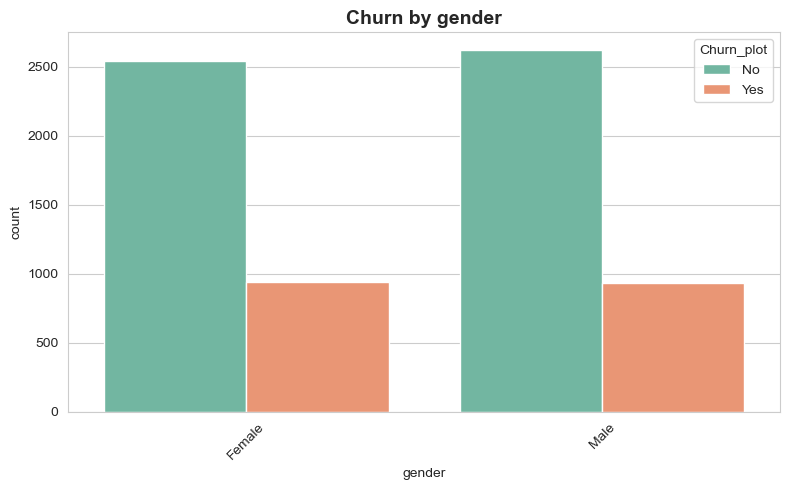


📌 Feature: Partner

Value Counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Value Counts (%):
Partner
No     51.75
Yes    48.25
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
Partner
No     32.98
Yes    19.72
Name: Churn_flag, dtype: float64


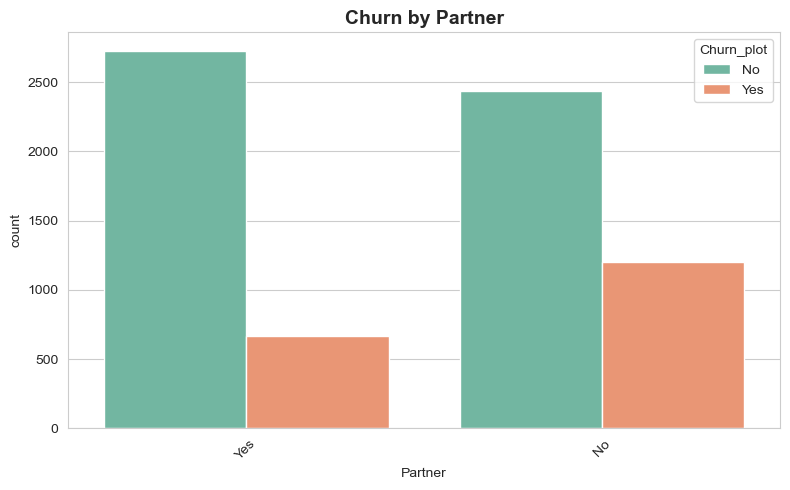


📌 Feature: Dependents

Value Counts:
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

Value Counts (%):
Dependents
No     70.15
Yes    29.85
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
Dependents
No     31.28
Yes    15.53
Name: Churn_flag, dtype: float64


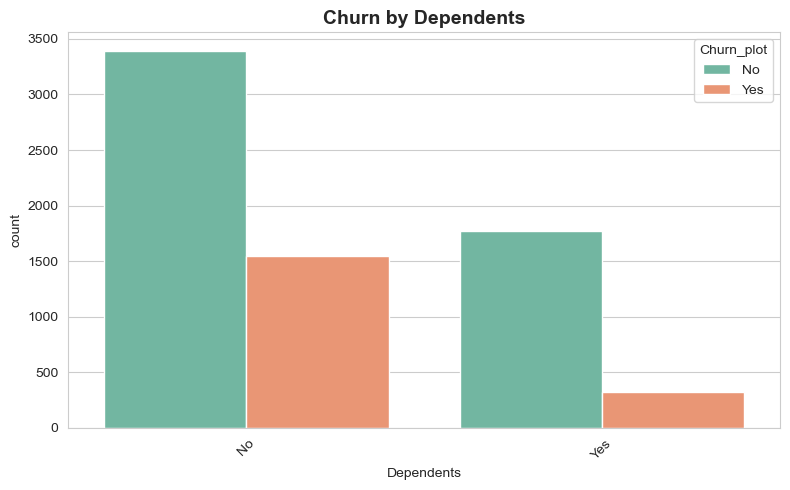


📌 Feature: PhoneService

Value Counts:
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

Value Counts (%):
PhoneService
Yes    90.33
No      9.67
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
PhoneService
Yes    26.75
No     25.00
Name: Churn_flag, dtype: float64


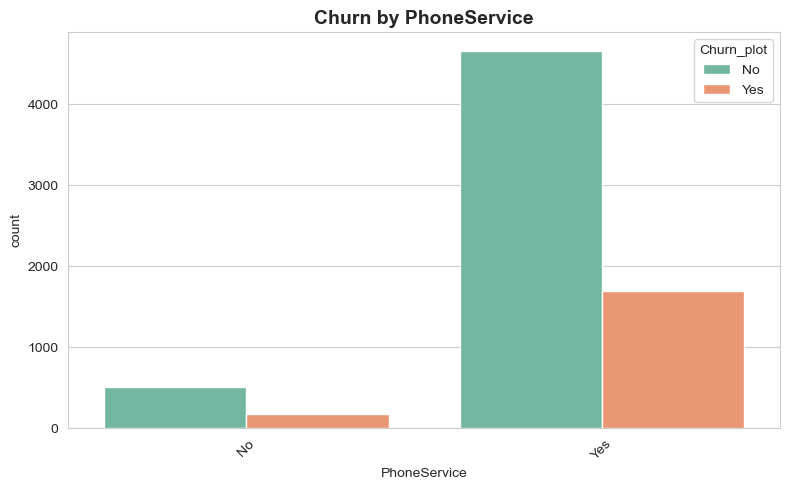


📌 Feature: MultipleLines

Value Counts:
MultipleLines
No     4065
Yes    2967
Name: count, dtype: int64

Value Counts (%):
MultipleLines
No     57.81
Yes    42.19
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
MultipleLines
Yes    28.65
No     25.07
Name: Churn_flag, dtype: float64


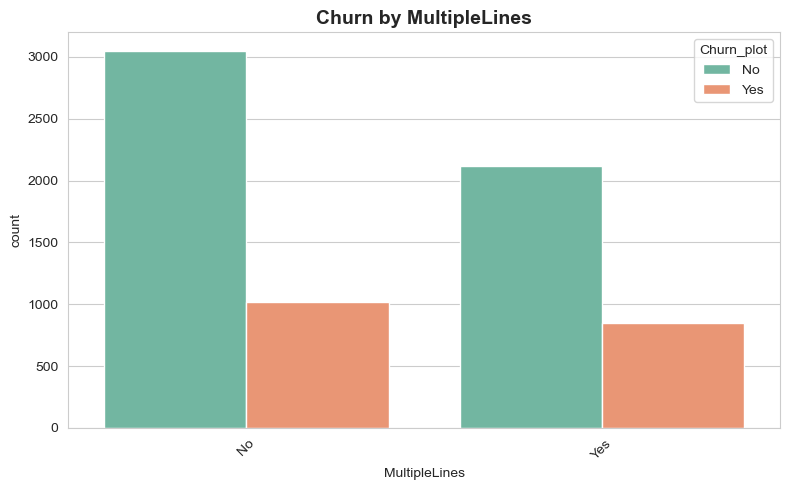


📌 Feature: InternetService

Value Counts:
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

Value Counts (%):
InternetService
Fiber optic    44.03
DSL            34.36
No             21.62
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn_flag, dtype: float64


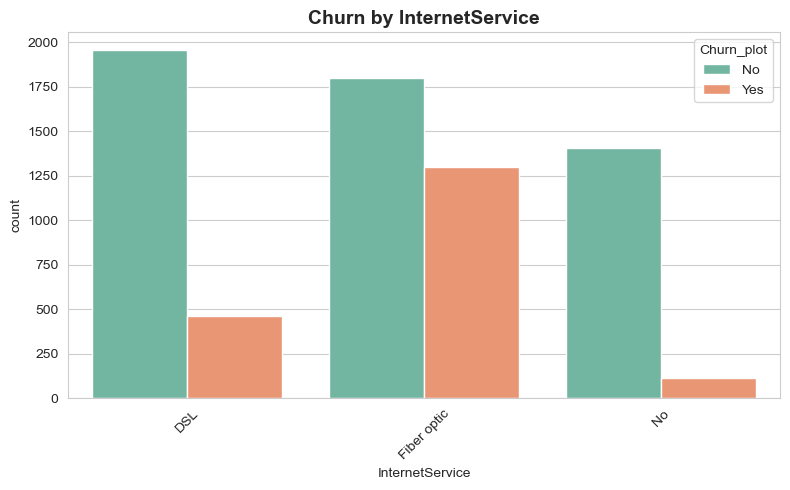


📌 Feature: OnlineSecurity

Value Counts:
OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64

Value Counts (%):
OnlineSecurity
No     71.35
Yes    28.65
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
OnlineSecurity
No     31.37
Yes    14.64
Name: Churn_flag, dtype: float64


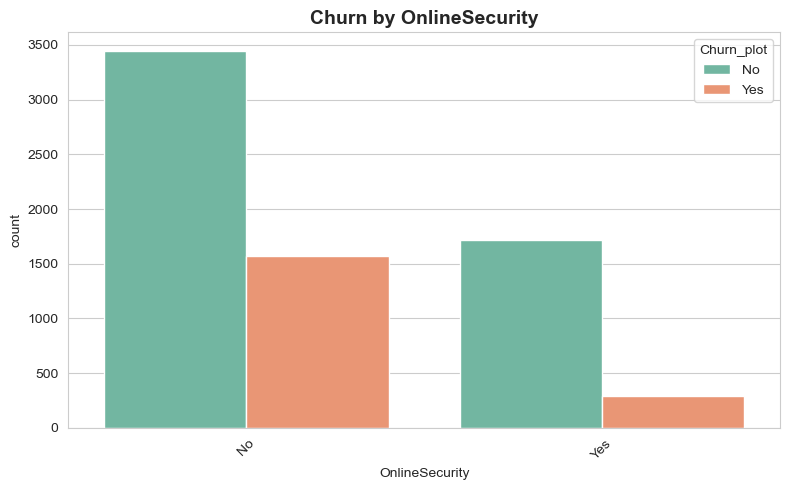


📌 Feature: OnlineBackup

Value Counts:
OnlineBackup
No     4607
Yes    2425
Name: count, dtype: int64

Value Counts (%):
OnlineBackup
No     65.51
Yes    34.49
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
OnlineBackup
No     29.22
Yes    21.57
Name: Churn_flag, dtype: float64


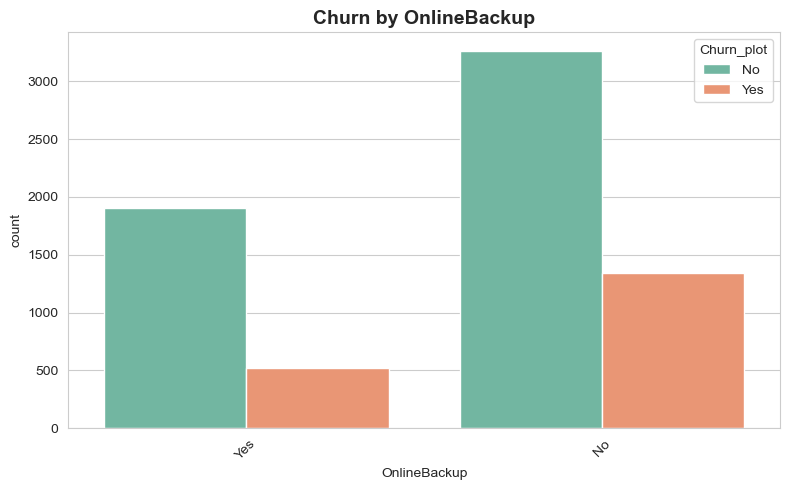


📌 Feature: DeviceProtection

Value Counts:
DeviceProtection
No     4614
Yes    2418
Name: count, dtype: int64

Value Counts (%):
DeviceProtection
No     65.61
Yes    34.39
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
DeviceProtection
No     28.70
Yes    22.54
Name: Churn_flag, dtype: float64


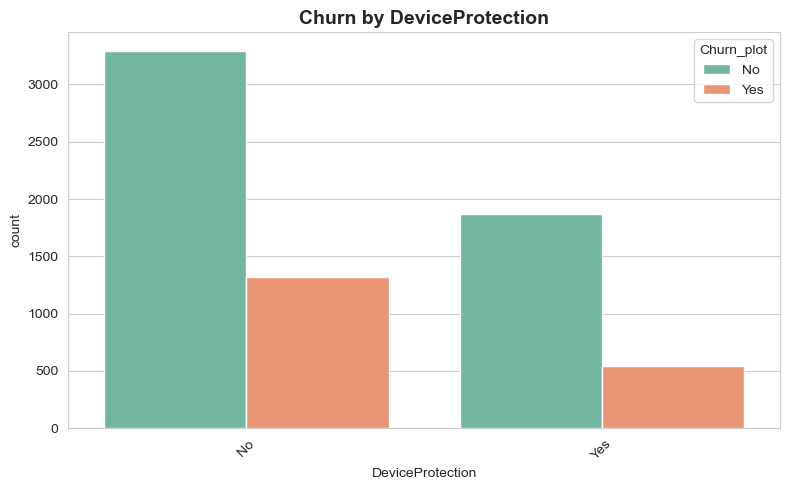


📌 Feature: TechSupport

Value Counts:
TechSupport
No     4992
Yes    2040
Name: count, dtype: int64

Value Counts (%):
TechSupport
No     70.99
Yes    29.01
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
TechSupport
No     31.23
Yes    15.20
Name: Churn_flag, dtype: float64


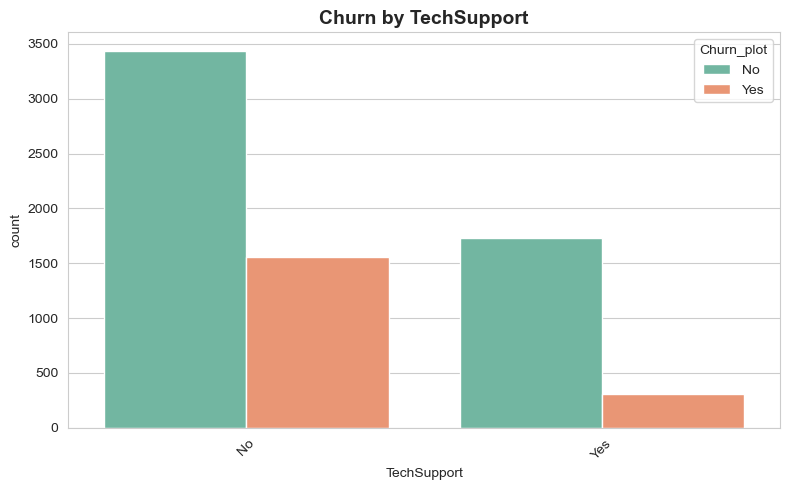


📌 Feature: StreamingTV

Value Counts:
StreamingTV
No     4329
Yes    2703
Name: count, dtype: int64

Value Counts (%):
StreamingTV
No     61.56
Yes    38.44
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
StreamingTV
Yes    30.11
No     24.37
Name: Churn_flag, dtype: float64


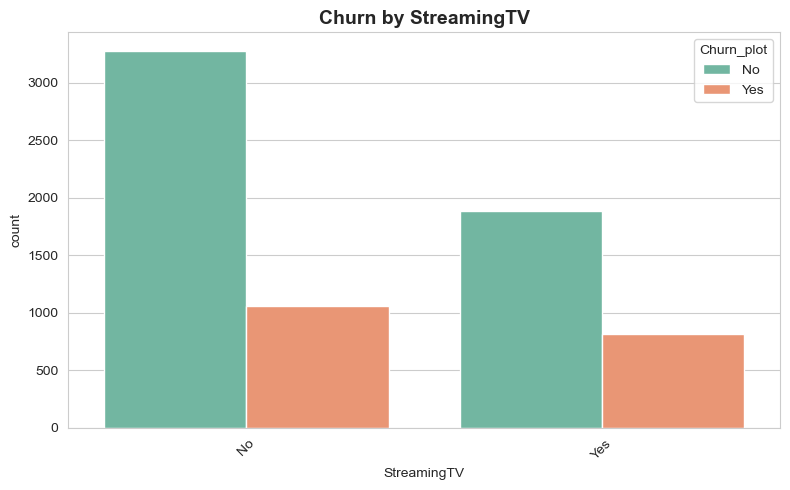


📌 Feature: StreamingMovies

Value Counts:
StreamingMovies
No     4301
Yes    2731
Name: count, dtype: int64

Value Counts (%):
StreamingMovies
No     61.16
Yes    38.84
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
StreamingMovies
Yes    29.95
No     24.44
Name: Churn_flag, dtype: float64


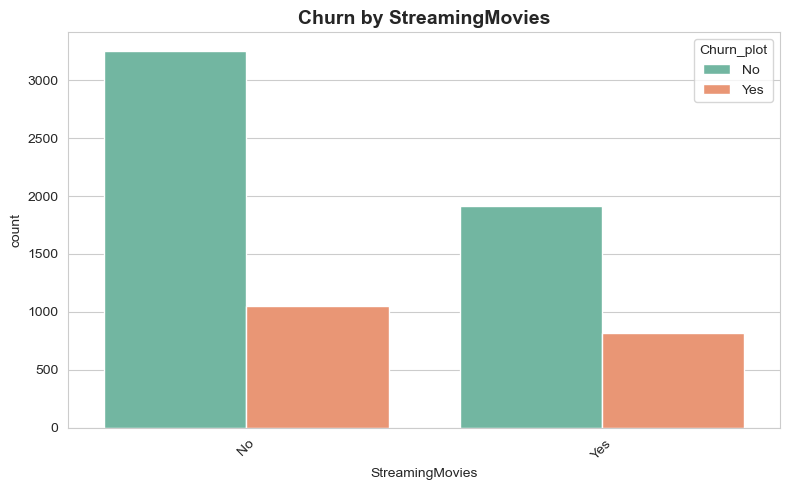


📌 Feature: Contract

Value Counts:
Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

Value Counts (%):
Contract
Month-to-month    55.11
Two year          23.96
One year          20.93
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn_flag, dtype: float64


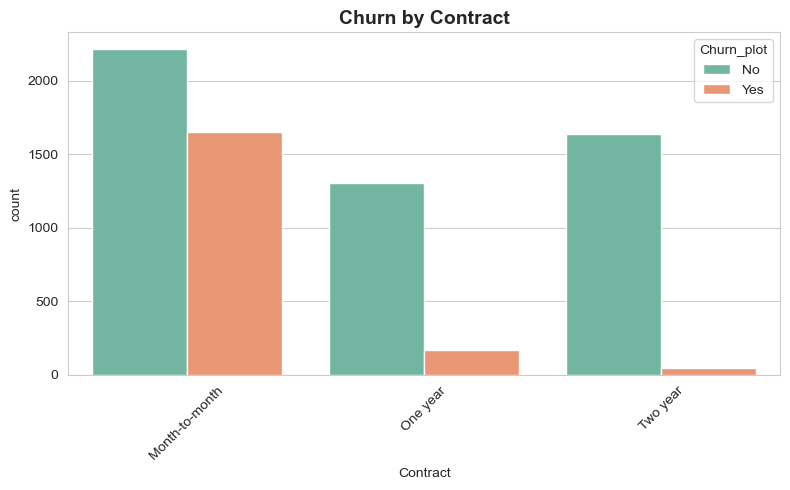


📌 Feature: PaperlessBilling

Value Counts:
PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

Value Counts (%):
PaperlessBilling
Yes    59.27
No     40.73
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
PaperlessBilling
Yes    33.59
No     16.38
Name: Churn_flag, dtype: float64


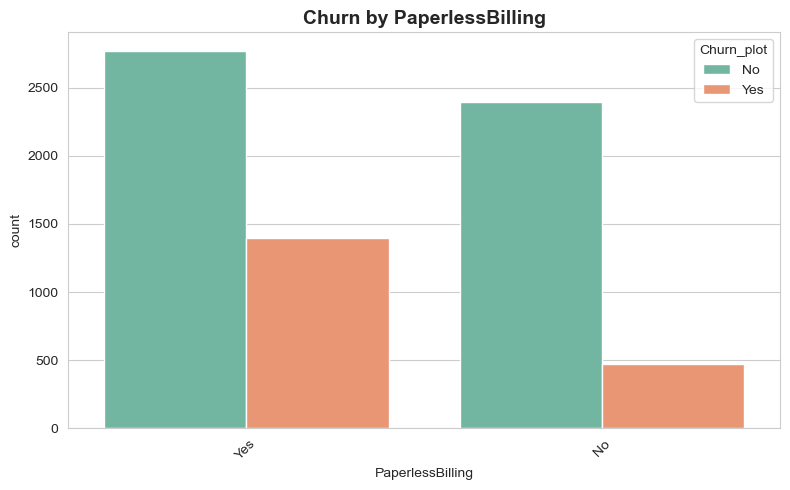


📌 Feature: PaymentMethod

Value Counts:
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

Value Counts (%):
PaymentMethod
Electronic check             33.63
Mailed check                 22.81
Bank transfer (automatic)    21.93
Credit card (automatic)      21.63
Name: proportion, dtype: float64

Churn Rate per Category (% of Yes):
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn_flag, dtype: float64


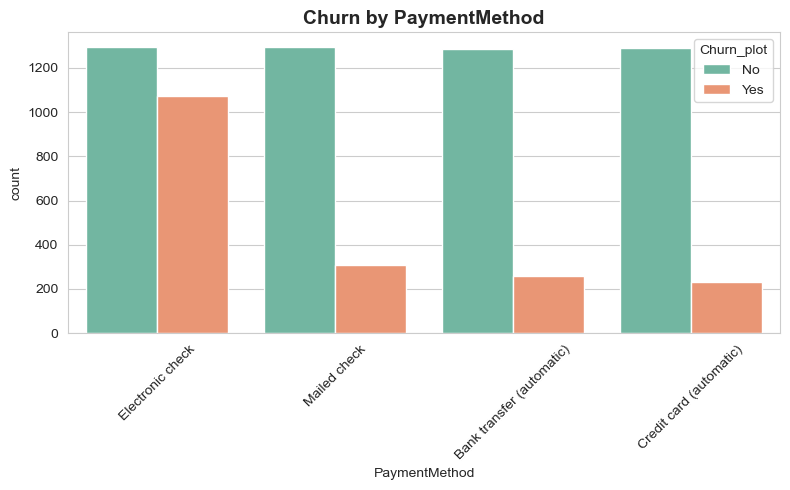

In [438]:
# ==============================
# Step 6 - Categorical Feature EDA
# ==============================

print("Churn_flag created. Value counts:")
print(data["Churn_flag"].value_counts(dropna=False))

categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [
    col for col in categorical_cols
    if col not in ["customerID", "Churn", "Churn_plot"]  # sadece feature kolonlar
]

print(f"\nTotal categorical feature columns: {len(categorical_cols)}")
print(categorical_cols)

for col in categorical_cols:
    print("\n" + "="*60)
    print(f"📌 Feature: {col}")
    print("="*60)
    
    # 1) Değer sayıları
    print("\nValue Counts:")
    print(data[col].value_counts())
    print("\nValue Counts (%):")
    print((data[col].value_counts(normalize=True) * 100).round(2))
    
 
    print("\nChurn Rate per Category (% of Yes):")
    churn_rate = (
        data.groupby(col)["Churn_flag"]
        .mean()
        .sort_values(ascending=False) * 100
    )
    print(churn_rate.round(2))
    
 
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=col, hue="Churn_plot", palette="Set2")
    plt.title(f"Churn by {col}", fontsize=14, fontweight="bold")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


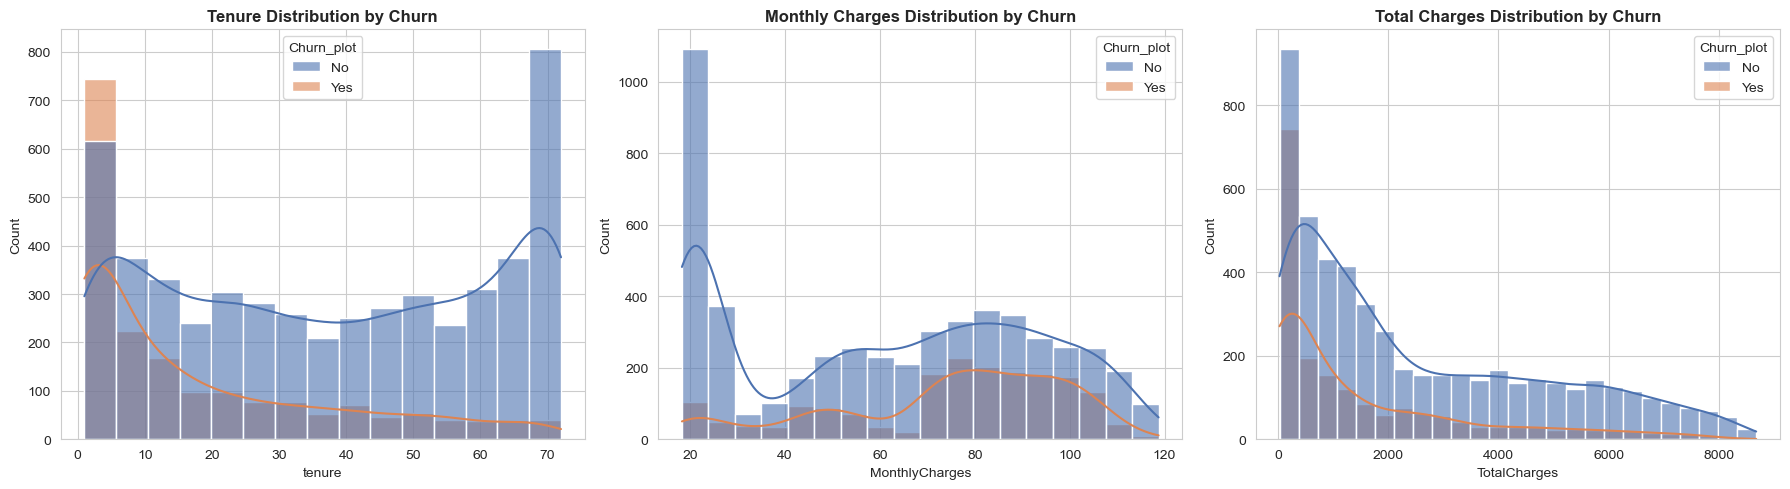

In [439]:
# ==============================
# Step 7 - Numeric Feature EDA (Histograms)
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn_plot her zaman Yes / No olduğu için:
colors = {"No": "#4C72B0", "Yes": "#DD8452"}

sns.histplot(
    data=data,
    x="tenure",
    hue="Churn_plot",
    kde=True,
    ax=axes[0],
    palette=colors,
    alpha=0.6
)
axes[0].set_title("Tenure Distribution by Churn", fontsize=12, fontweight="bold")

sns.histplot(
    data=data,
    x="MonthlyCharges",
    hue="Churn_plot",
    kde=True,
    ax=axes[1],
    palette=colors,
    alpha=0.6
)
axes[1].set_title("Monthly Charges Distribution by Churn", fontsize=12, fontweight="bold")

sns.histplot(
    data=data,
    x="TotalCharges",
    hue="Churn_plot",
    kde=True,
    ax=axes[2],
    palette=colors,
    alpha=0.6
)
axes[2].set_title("Total Charges Distribution by Churn", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


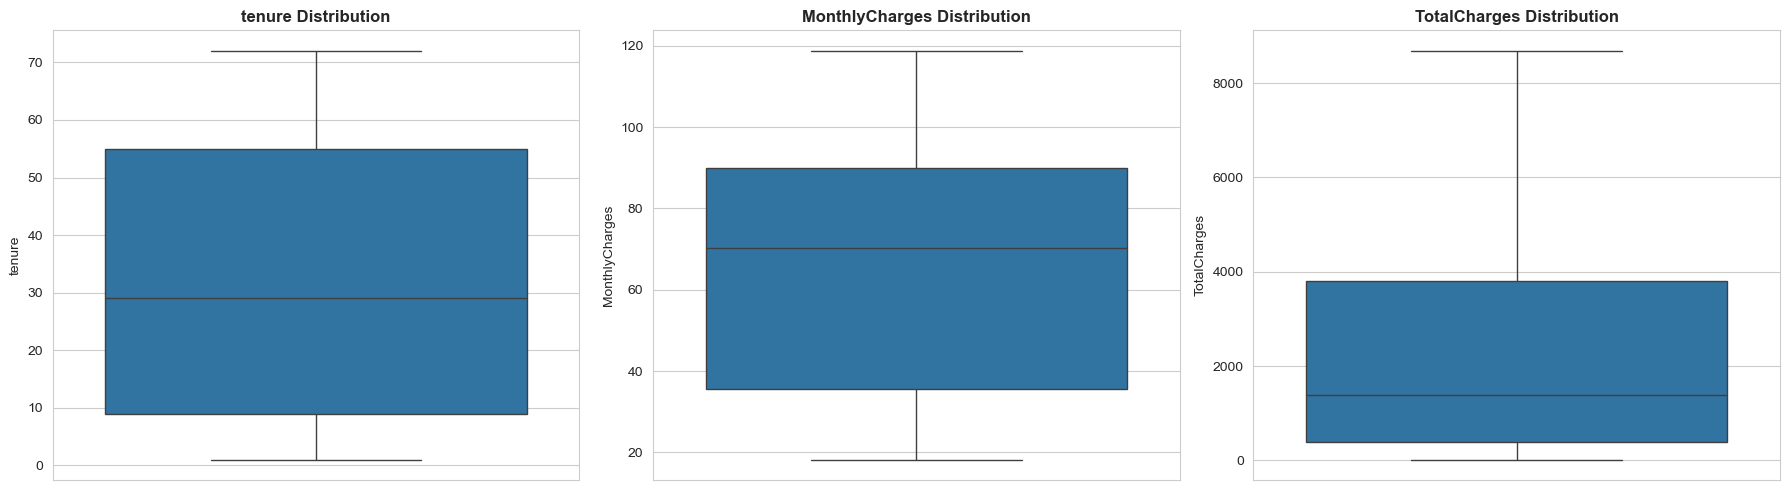


Outlier Analysis:

tenure:
  Outliers: 0 (0.00%)
  Lower bound: -60.00
  Upper bound: 124.00

MonthlyCharges:
  Outliers: 0 (0.00%)
  Lower bound: -45.82
  Upper bound: 171.27

TotalCharges:
  Outliers: 0 (0.00%)
  Lower bound: -4688.48
  Upper bound: 8884.67

No outliers were detected using the IQR method.


In [440]:
# ==============================
# Step 8 - Outlier Analysis
# ==============================

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=data, y=col, ax=axes[idx])
    axes[idx].set_title(f"{col} Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print("\nOutlier Analysis:")
print("="*50)

total_outliers = 0

for col in numeric_cols:
    count, lower, upper = count_outliers(data[col])
    total_outliers += count
    print(f"\n{col}:")
    print(f"  Outliers: {count} ({count/len(data)*100:.2f}%)")
    print(f"  Lower bound: {lower:.2f}")
    print(f"  Upper bound: {upper:.2f}")

print("\n" + "="*50)
if total_outliers == 0:
    print("No outliers were detected using the IQR method.")
else:
    print("Outliers were detected but not removed, as they may represent valid customer segments.")


In [495]:
# ==============================
# Step 9 - Rare Category Analysis
# ==============================

categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ["customerID", "Churn"]]

print("\nRelative Frequency of Categories:")
print("="*60)
for col in categorical_cols:
    print(f"\n{col}:")
    freq = data[col].value_counts(normalize=True) * 100
    print(freq)
    rare = freq[freq < 1]
    if len(rare) > 0:
        print(f"  ⚠️ Rare categories (< 1%): {list(rare.index)}")
    else:
        print("  ✓ No rare categories found")




Relative Frequency of Categories:

gender:
gender
Male      50.469283
Female    49.530717
Name: proportion, dtype: float64
  ✓ No rare categories found

Partner:
Partner
No     51.749147
Yes    48.250853
Name: proportion, dtype: float64
  ✓ No rare categories found

Dependents:
Dependents
No     70.150739
Yes    29.849261
Name: proportion, dtype: float64
  ✓ No rare categories found

PhoneService:
PhoneService
Yes    90.32992
No      9.67008
Name: proportion, dtype: float64
  ✓ No rare categories found

MultipleLines:
MultipleLines
No     57.807167
Yes    42.192833
Name: proportion, dtype: float64
  ✓ No rare categories found

InternetService:
InternetService
Fiber optic    44.027304
DSL            34.357224
No             21.615472
Name: proportion, dtype: float64
  ✓ No rare categories found

OnlineSecurity:
OnlineSecurity
No     71.345279
Yes    28.654721
Name: proportion, dtype: float64
  ✓ No rare categories found

OnlineBackup:
OnlineBackup
No     65.51479
Yes    34.48521
Name: 


Target distribution:
Churn_flag
0    5163
1    1869
Name: count, dtype: int64
Churn rate: 26.58%

Correlation matrix (numeric features + Churn_flag):
                  tenure  MonthlyCharges  TotalCharges  Churn_flag
tenure          1.000000        0.246862      0.825880   -0.354049
MonthlyCharges  0.246862        1.000000      0.651065    0.192858
TotalCharges    0.825880        0.651065      1.000000   -0.199484
Churn_flag     -0.354049        0.192858     -0.199484    1.000000


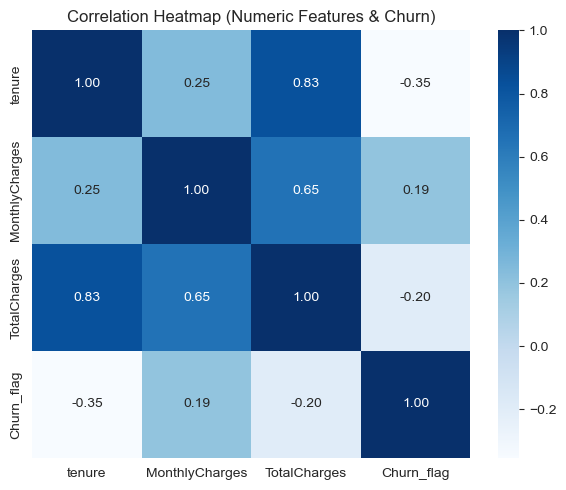

In [442]:
# ==============================
# Step 10 - Target Encoding & Correlation
# ==============================

print("\nTarget distribution:")
print(data["Churn_flag"].value_counts())
print(f"Churn rate: {data['Churn_flag'].mean()*100:.2f}%")

# Correlation of numeric features with Churn_flag
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_flag"]
corr_matrix = data[corr_cols].corr()

print("\nCorrelation matrix (numeric features + Churn_flag):")
print(corr_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features & Churn)")
plt.tight_layout()
plt.show()



Categorical columns used in Cramér’s V:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


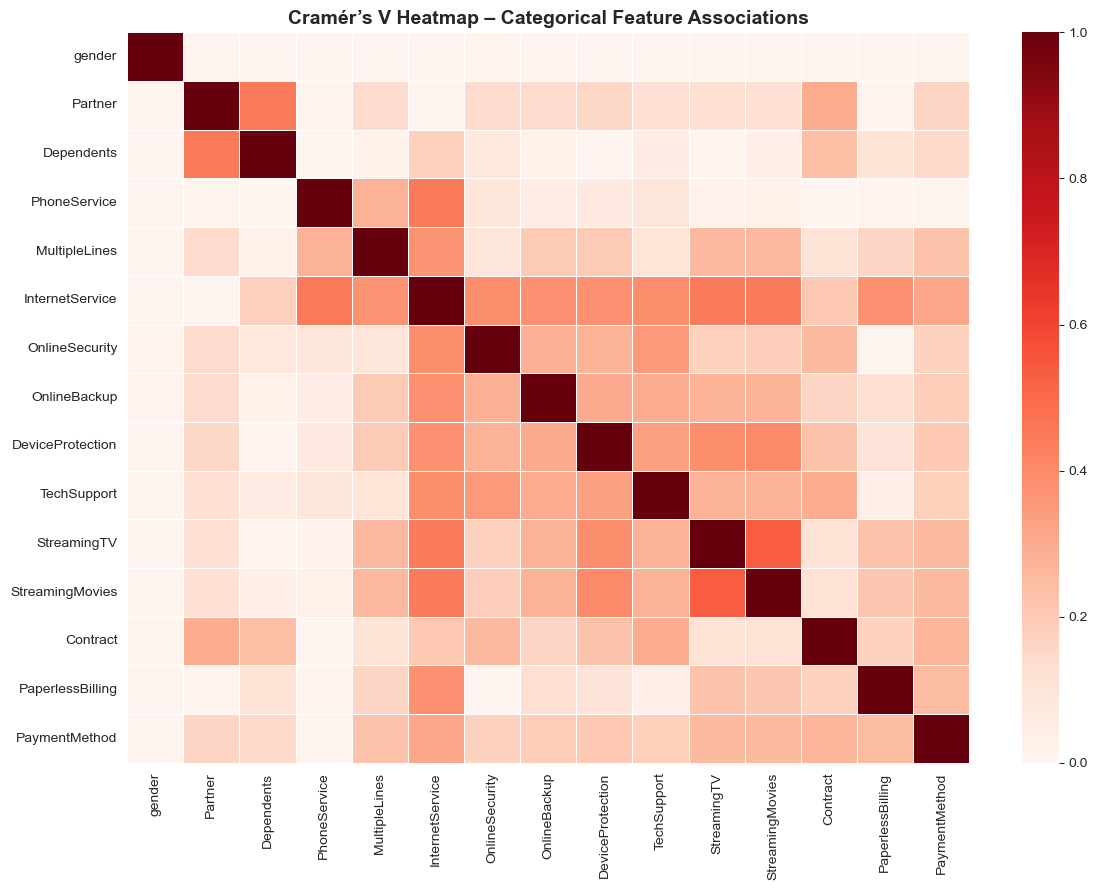


Top associations with Churn:
Contract            0.409242
InternetService     0.321490
PaymentMethod       0.302276
PaperlessBilling    0.190768
OnlineSecurity      0.170509
TechSupport         0.163940
Dependents          0.162351
Partner             0.149194
OnlineBackup        0.081102
DeviceProtection    0.064769
dtype: float64


In [443]:
# ==============================
# ==============================
# Step 10b - Cramér's V Categorical Correlation Matrix
# ==============================
# Cramér's V measures association between categorical variables
# Values range from 0 (no association) to 1 (perfect association)

# ==============================


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    # Eğer biri tek kategoriye sahipse, ilişki tanımlı değil → 0 döndür
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return 0.0

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    r_corr = r - ((r - 1)**2) / (n - 1)
    k_corr = k - ((k - 1)**2) / (n - 1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return 0.0

    return np.sqrt(phi2_corr / denom)

# 1) Kategorik kolonlar (ID ve target türevlerini hariç tut)
categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [
    col for col in categorical_cols
    if col not in ["customerID", "Churn", "Churn_plot"]
]

print("\nCategorical columns used in Cramér’s V:")
print(categorical_cols)

# 2) Boş matris
cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_cols), len(categorical_cols))),
    index=categorical_cols,
    columns=categorical_cols
)

# 3) Matris doldurma
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# 4) Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(cramers_matrix, annot=False, cmap="Reds", linewidths=0.5)
plt.title("Cramér’s V Heatmap – Categorical Feature Associations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 5) Churn ile en ilişkili kategorik değişkenler (Churn_plot üzerinden)
assoc_with_churn = {}

for col in categorical_cols:
    assoc_with_churn[col] = cramers_v(data[col], data["Churn_plot"])

assoc_with_churn = pd.Series(assoc_with_churn).sort_values(ascending=False)

print("\nTop associations with Churn:")
print(assoc_with_churn.head(10))


In [493]:
# ==============================
# Step 10c - Feature Engineering: One-Hot Encoding
# ==============================
# One-hot encoding is applied to all categorical features
# drop_first=True is used to avoid multicollinearity

# Kullanılmayacak kolonları çıkar
# - customerID → kimlik bilgisi
# - Churn_flag → hedef (y)
# - Churn_plot → sadece grafik için gerekli, model girmemeli
# - Churn → orijinal target, artık gereksiz

X = data.drop(["customerID", "Churn", "Churn_flag", "Churn_plot"], axis=1, errors="ignore")
y = data["Churn_flag"]

print(f"\nFeatures shape before encoding: {X.shape}")

# One-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"\nFeatures shape after encoding: {X_encoded.shape}")
print("\nExample of encoded columns:")
print(list(X_encoded.columns)[:20])

print("\nClass distribution (y):")
print(y.value_counts())
print("\nPercentage:")
print((y.value_counts(normalize=True) * 100).round(2))



Features shape before encoding: (7032, 19)

Features shape after encoding: (7032, 23)

Example of encoded columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes']

Class distribution (y):
Churn_flag
0    5163
1    1869
Name: count, dtype: int64

Percentage:
Churn_flag
0    73.42
1    26.58
Name: proportion, dtype: float64


In [445]:
# ==============================
# Step 10d - Train/Test Split
# ==============================

TEST_SIZE = 0.20
TRAIN_SIZE = 1 - TEST_SIZE

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train–Test Split Summary")
print("="*40)
print(f"Training set ratio : {TRAIN_SIZE*100:.0f}%")
print(f"Test set ratio     : {TEST_SIZE*100:.0f}%")

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape    : {X_test.shape}")

print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTraining set class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest set class distribution:")
print(y_test.value_counts())
print("\nTest set class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))



Train–Test Split Summary
Training set ratio : 80%
Test set ratio     : 20%

Training set shape: (5625, 23)
Test set shape    : (1407, 23)

Training set class distribution:
Churn_flag
0    4130
1    1495
Name: count, dtype: int64

Training set class distribution (%):
Churn_flag
0    73.42
1    26.58
Name: proportion, dtype: float64

Test set class distribution:
Churn_flag
0    1033
1     374
Name: count, dtype: int64

Test set class distribution (%):
Churn_flag
0    73.42
1    26.58
Name: proportion, dtype: float64


In [446]:
# ==============================
# Step 11 - Logistic Regression + SMOTE + 5-Fold CV
# ==============================

lr_pipeline = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("lr", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_lr = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# Özet tablo (mean ± std)
rows = []
for m in scoring.keys():
    rows.append({
        "Metric": m,
        "Train Mean": cv_results_lr[f"train_{m}"].mean(),
        "Train Std":  cv_results_lr[f"train_{m}"].std(),
        "CV Mean":    cv_results_lr[f"test_{m}"].mean(),
        "CV Std":     cv_results_lr[f"test_{m}"].std(),
    })

lr_cv_summary = pd.DataFrame(rows)
display(lr_cv_summary)


,Metric,Train Mean,Train Std,CV Mean,CV Std
0,accuracy,0.759422,0.003345,0.754311,0.007428
1,precision,0.531581,0.004535,0.525098,0.009377
2,recall,0.799164,0.005000,0.791973,0.019775
3,f1,0.638447,0.003018,0.631426,0.011464
4,roc_auc,0.850965,0.001350,0.845793,0.005483


In [448]:
# ==============================
# Step 13 - LR + SMOTE → Train full / Evaluate on Test
# ==============================
# Model is trained on full training set and evaluated on held-out test set
# Test set is never used during training or cross-validation

# Pipeline zaten tanımlı: lr_pipeline
lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression + SMOTE — TEST SET RESULTS")
print("="*55)
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

y_pred_lr_smote = y_pred
y_proba_lr_smote = y_proba



Logistic Regression + SMOTE — TEST SET RESULTS
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.8339541131950449

Confusion Matrix:
[[740 293]
 [ 82 292]]


In [449]:
# ==============================
# Step 12 - XGBoost + SMOTE + 5-Fold CV
# ==============================
# Pipeline order: SMOTE → XGBClassifier
# SMOTE is applied first to balance classes before XGBoost training

xgb_pipeline = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("xgb", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_xgb = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

rows = []
for m in scoring.keys():
    rows.append({
        "Metric": m,
        "Train Mean": cv_results_xgb[f"train_{m}"].mean(),
        "Train Std":  cv_results_xgb[f"train_{m}"].std(),
        "CV Mean":    cv_results_xgb[f"test_{m}"].mean(),
        "CV Std":     cv_results_xgb[f"test_{m}"].std(),
    })

xgb_cv_summary = pd.DataFrame(rows)
display(xgb_cv_summary)


,Metric,Train Mean,Train Std,CV Mean,CV Std
0,accuracy,0.846622,0.002781,0.788800,0.004856
1,precision,0.702898,0.005130,0.597269,0.010008
2,recall,0.732609,0.010765,0.631438,0.018609
3,f1,0.717403,0.006130,0.613697,0.009975
4,roc_auc,0.911389,0.002455,0.834269,0.007473


In [451]:
# ==============================
# Step 14 - XGB + SMOTE → Train full / Evaluate on Test
# ==============================
# Model is trained on full training set and evaluated on held-out test set
# Test set is never used during training or cross-validation

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost + SMOTE — TEST SET RESULTS")
print("="*55)
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

y_pred_xgb_smote = y_pred_xgb
y_proba_xgb_smote = y_proba_xgb


XGBoost + SMOTE — TEST SET RESULTS
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1033
           1       0.55      0.61      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.8192534076025904

Confusion Matrix:
[[849 184]
 [146 228]]


In [454]:
# ==============================
# Step 12b - XGBoost (NO SMOTE) + scale_pos_weight + 5-Fold CV
# ==============================

# 1) scale_pos_weight sadece TRAIN'den hesaplanmalı
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.4f}  (neg={neg}, pos={pos})")

# 2) Pipeline: sadece XGB (SMOTE yok)
xgb_weight_pipeline = ImbPipeline(steps=[
    ("xgb", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3) scoring (SMOTE tarafıyla birebir aynı tutalım)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
    # istersen ekleyebilirsin:
    # "pr_auc": "average_precision"
}

cv_results_xgb_weight = cross_validate(
    xgb_weight_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

rows = []
for m in scoring.keys():
    rows.append({
        "Metric": m,
        "Train Mean": cv_results_xgb_weight[f"train_{m}"].mean(),
        "Train Std":  cv_results_xgb_weight[f"train_{m}"].std(),
        "CV Mean":    cv_results_xgb_weight[f"test_{m}"].mean(),
        "CV Std":     cv_results_xgb_weight[f"test_{m}"].std(),
    })

xgb_weight_cv_summary = pd.DataFrame(rows)
display(xgb_weight_cv_summary)


scale_pos_weight = 2.7625  (neg=4130, pos=1495)


,Metric,Train Mean,Train Std,CV Mean,CV Std
0,accuracy,0.833867,0.002650,0.757333,0.006604
1,precision,0.630850,0.003846,0.530768,0.009121
2,recall,0.903846,0.005912,0.753177,0.016975
3,f1,0.743058,0.003897,0.622599,0.009034
4,roc_auc,0.931649,0.001156,0.840869,0.006107


In [456]:
# ==============================
# XGBoost + scale_pos_weight — Train full / Evaluate on Test (PIPELINE)
# ==============================

# CV'de kullandığın pipeline'ı burada da kullan
xgb_weight_pipeline.fit(X_train, y_train)

y_pred_xgb_weighted  = xgb_weight_pipeline.predict(X_test)
y_proba_xgb_weighted = xgb_weight_pipeline.predict_proba(X_test)[:, 1]

print("\nXGBoost + scale_pos_weight — TEST SET RESULTS (PIPELINE)")
print("="*55)
print(classification_report(y_test, y_pred_xgb_weighted, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_weighted))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb_weighted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_weighted))



XGBoost + scale_pos_weight — TEST SET RESULTS (PIPELINE)
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.8254901097990901
PR-AUC: 0.6316100382148448

Confusion Matrix:
[[748 285]
 [ 88 286]]


MODEL COMPARISON SUMMARY (Test Set) - ALL THREE MODELS

Class Imbalance Handling Methods:
  - Logistic Regression + SMOTE: Uses SMOTE (required for linear models)
  - XGBoost + SMOTE: Uses SMOTE (oversampling)
  - XGBoost + scale_pos_weight: Uses class weighting (preferred for tree models)

All models evaluated on the SAME test set (no data leakage).



,Model,Accuracy,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1),ROC-AUC,PR-AUC (AP)
0,Logistic Regression + SMOTE,0.7335,0.4991,0.7807,0.6090,0.8340,0.6239
1,XGBoost + SMOTE,0.7655,0.5534,0.6096,0.5802,0.8193,0.6220
2,XGBoost + scale_pos_weight,0.7349,0.5009,0.7647,0.6053,0.8255,0.6316


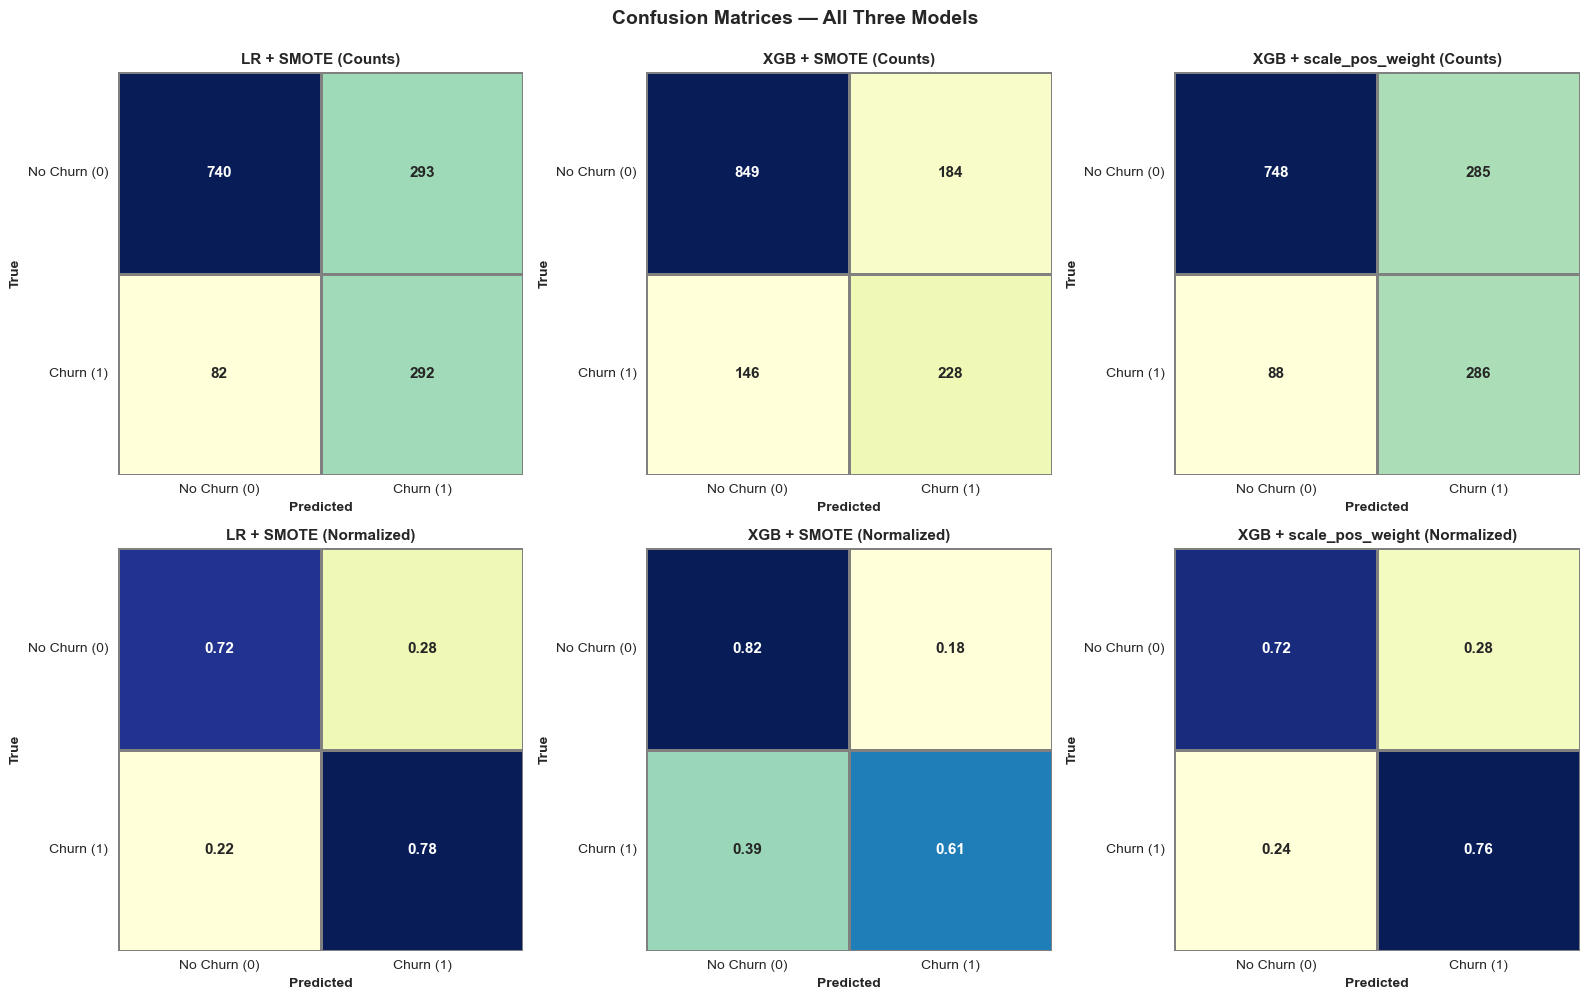

<Figure size 800x600 with 0 Axes>

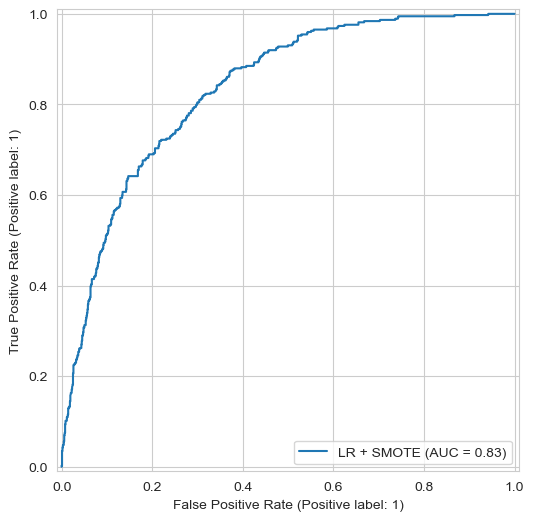

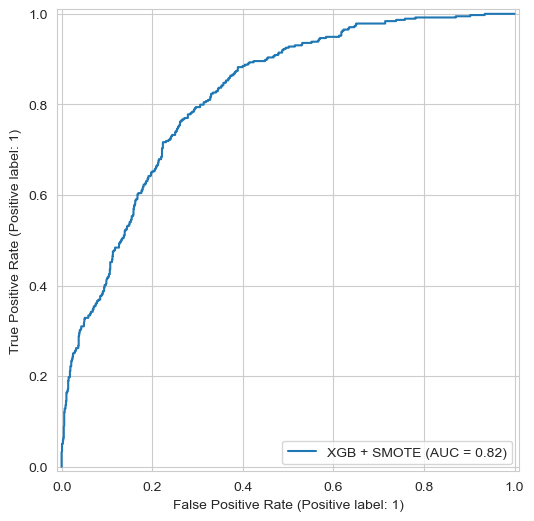

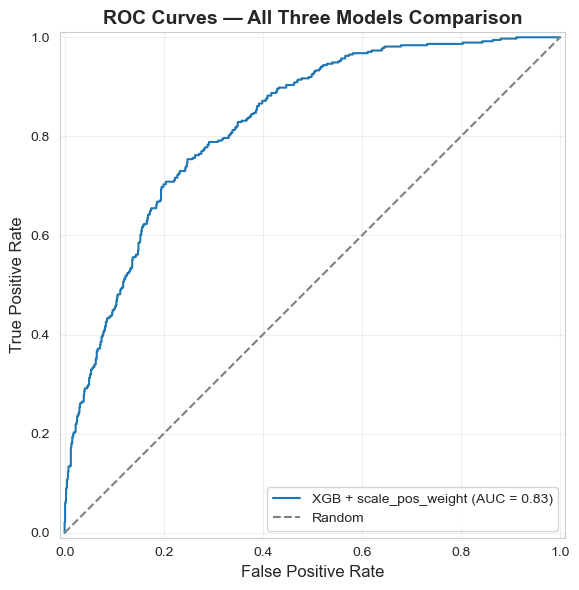

<Figure size 800x600 with 0 Axes>

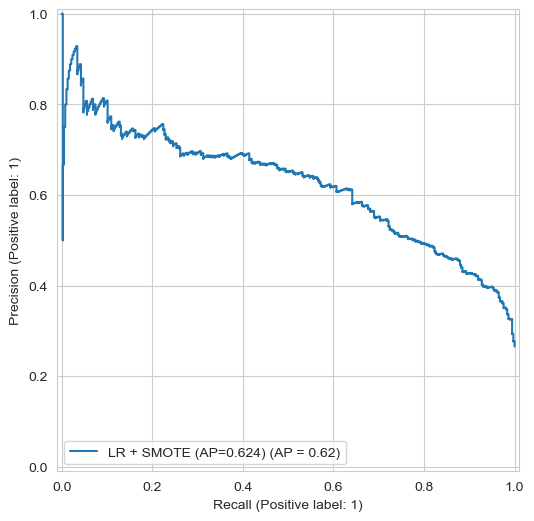

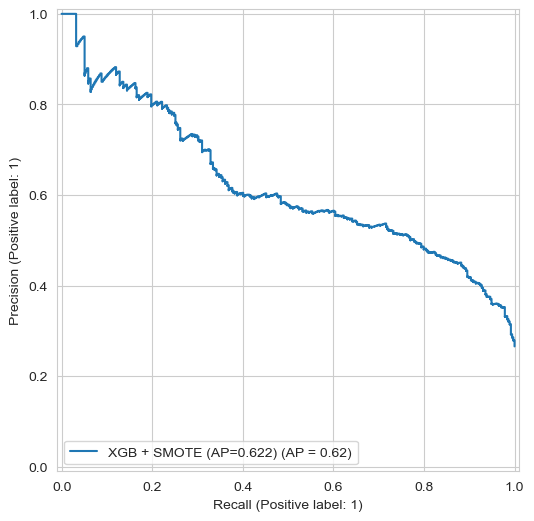

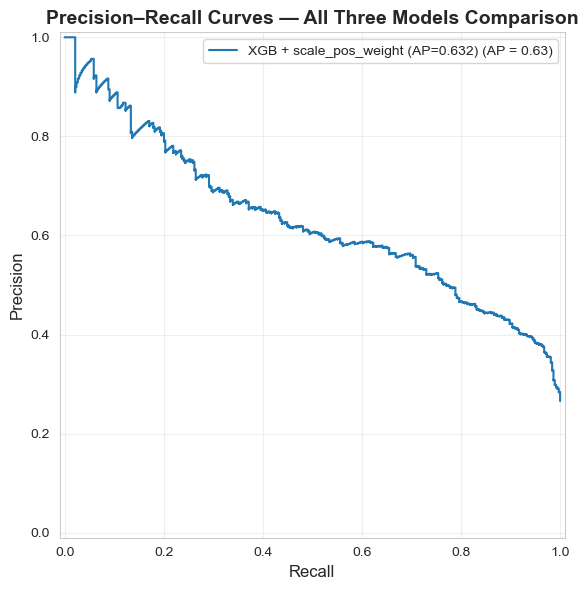

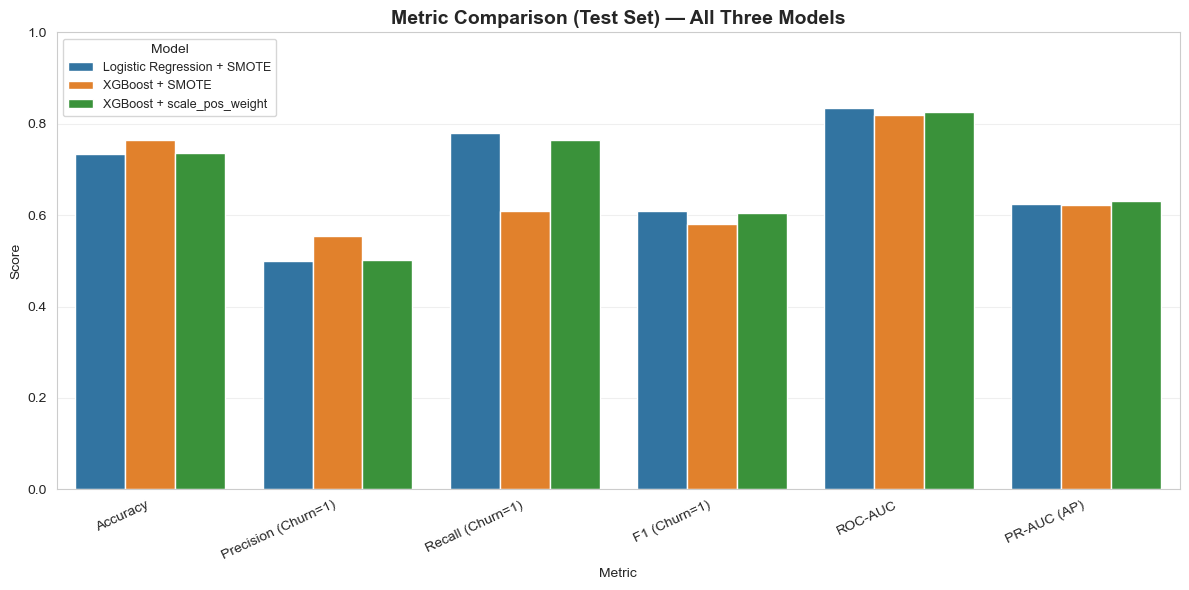


📝 SUMMARY: XGBoost + SMOTE vs XGBoost + scale_pos_weight

XGBoost + SMOTE might be preferred when:
  - You want explicit class balancing through synthetic sample generation
  - You need to ensure equal representation of both classes in training
  - You're comparing with other models that use SMOTE (for consistency)
  - You have sufficient computational resources for SMOTE overhead

XGBoost + scale_pos_weight is preferred when:
  - You want faster training (no synthetic sample generation)
  - You want to preserve the original data distribution
  - You prefer class weighting over oversampling for tree models
  - You're working with large datasets where SMOTE would be slow
  - You want a simpler pipeline (no SMOTE step needed)

Both methods are valid and academically correct. The choice depends on:
  - Computational constraints
  - Preference for synthetic vs weighted training
  - Specific requirements of your use case



In [457]:
# ==============================
# Step 15 - Final Model Comparison (Test Set) - ALL THREE MODELS
# ==============================
# Comprehensive comparison of ALL THREE models on the held-out test set
# All metrics are computed on the same test data for fair comparison
#
# METHODOLOGY NOTES:
# - Logistic Regression + SMOTE: 
#   * SMOTE is REQUIRED for Logistic Regression because it's a linear model
#   * Linear models are sensitive to class imbalance and benefit from balanced training data
#   * SMOTE creates synthetic samples to balance classes before training
#
# - XGBoost + SMOTE:
#   * SMOTE can be used with tree-based models, but it's not always necessary
#   * Tree models are less sensitive to class imbalance than linear models
#   * SMOTE increases training time and creates synthetic data
#
# - XGBoost + scale_pos_weight:
#   * PREFERRED for XGBoost because it's faster and preserves original data distribution
#   * scale_pos_weight adjusts class weights during training without creating synthetic samples
#   * Computationally more efficient than SMOTE for tree-based models
#
# - PR-AUC (Average Precision) is IMPORTANT for imbalanced churn problems:
#   * ROC-AUC can be misleading with imbalanced data (optimistic scores)
#   * PR-AUC focuses on the positive class (churn) and is more informative
#   * PR-AUC penalizes false positives more heavily, which is critical for churn prediction
#   * Higher PR-AUC indicates better precision-recall trade-off for the minority class

def compute_metrics(name, y_true, y_pred, y_proba):
    """Compute all evaluation metrics for a model."""
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Churn=1)": precision_score(y_true, y_pred),
        "Recall (Churn=1)": recall_score(y_true, y_pred),
        "F1 (Churn=1)": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC (AP)": average_precision_score(y_true, y_proba),
    }

# Compute metrics for ALL THREE models
metrics_lr  = compute_metrics("Logistic Regression + SMOTE", y_test, y_pred_lr_smote,  y_proba_lr_smote)
metrics_xgb = compute_metrics("XGBoost + SMOTE",             y_test, y_pred_xgb_smote, y_proba_xgb_smote)
metrics_xgb_weighted = compute_metrics("XGBoost + scale_pos_weight", y_test, y_pred_xgb_weighted, y_proba_xgb_weighted)

results_df = pd.DataFrame([metrics_lr, metrics_xgb, metrics_xgb_weighted])

# Display formatted results table
print("="*70)
print("MODEL COMPARISON SUMMARY (Test Set) - ALL THREE MODELS")
print("="*70)
print("\nClass Imbalance Handling Methods:")
print("  - Logistic Regression + SMOTE: Uses SMOTE (required for linear models)")
print("  - XGBoost + SMOTE: Uses SMOTE (oversampling)")
print("  - XGBoost + scale_pos_weight: Uses class weighting (preferred for tree models)")
print("\nAll models evaluated on the SAME test set (no data leakage).\n")
display(results_df.round(4))

# Confusion Matrices - ALL THREE MODELS
def plot_cm(ax, y_true, y_pred, title, normalize=False):
    """Plot confusion matrix on given axes."""
    cm = confusion_matrix(y_true, y_pred, normalize="true" if normalize else None)
    fmt = ".2f" if normalize else "d"
    sns.heatmap(
        cm, annot=True, fmt=fmt, cbar=False, ax=ax,
        cmap="YlGnBu", linewidths=0.8, linecolor="gray",
        annot_kws={"size": 11, "weight": "bold"}
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10, fontweight="bold")
    ax.set_ylabel("True", fontsize=10, fontweight="bold")
    ax.set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)
    ax.set_yticklabels(["No Churn (0)", "Churn (1)"], rotation=0)

# Confusion matrices: 3 models x 2 views (counts + normalized) = 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_cm(axes[0,0], y_test, y_pred_lr_smote,  "LR + SMOTE (Counts)", normalize=False)
plot_cm(axes[0,1], y_test, y_pred_xgb_smote, "XGB + SMOTE (Counts)", normalize=False)
plot_cm(axes[0,2], y_test, y_pred_xgb_weighted, "XGB + scale_pos_weight (Counts)", normalize=False)
plot_cm(axes[1,0], y_test, y_pred_lr_smote,  "LR + SMOTE (Normalized)", normalize=True)
plot_cm(axes[1,1], y_test, y_pred_xgb_smote, "XGB + SMOTE (Normalized)", normalize=True)
plot_cm(axes[1,2], y_test, y_pred_xgb_weighted, "XGB + scale_pos_weight (Normalized)", normalize=True)
plt.suptitle("Confusion Matrices — All Three Models", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

# ROC Curves Comparison - ALL THREE MODELS
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr_smote,  name="LR + SMOTE")
RocCurveDisplay.from_predictions(y_test, y_proba_xgb_smote, name="XGB + SMOTE")
RocCurveDisplay.from_predictions(y_test, y_proba_xgb_weighted, name="XGB + scale_pos_weight")
plt.plot([0,1],[0,1],"--", color="gray", label="Random", linewidth=1.5)
plt.title("ROC Curves — All Three Models Comparison", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision–Recall Curves Comparison - ALL THREE MODELS
plt.figure(figsize=(8,6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr_smote,  name=f"LR + SMOTE (AP={average_precision_score(y_test, y_proba_lr_smote):.3f})")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb_smote, name=f"XGB + SMOTE (AP={average_precision_score(y_test, y_proba_xgb_smote):.3f})")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb_weighted, name=f"XGB + scale_pos_weight (AP={average_precision_score(y_test, y_proba_xgb_weighted):.3f})")
plt.title("Precision–Recall Curves — All Three Models Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Metric Bar Chart - ALL THREE MODELS
plot_cols = ["Accuracy", "Precision (Churn=1)", "Recall (Churn=1)", "F1 (Churn=1)", "ROC-AUC", "PR-AUC (AP)"]
df_long = results_df.melt(id_vars="Model", value_vars=plot_cols, var_name="Metric", value_name="Score")
plt.figure(figsize=(12,6))
sns.barplot(data=df_long, x="Metric", y="Score", hue="Model")
plt.title("Metric Comparison (Test Set) — All Three Models", fontsize=14, fontweight="bold")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Model", fontsize=9, title_fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ==============================
# Summary: When to use XGBoost + SMOTE vs XGBoost + scale_pos_weight
# ==============================
print("\n" + "="*70)
print("📝 SUMMARY: XGBoost + SMOTE vs XGBoost + scale_pos_weight")
print("="*70)
print("""
XGBoost + SMOTE might be preferred when:
  - You want explicit class balancing through synthetic sample generation
  - You need to ensure equal representation of both classes in training
  - You're comparing with other models that use SMOTE (for consistency)
  - You have sufficient computational resources for SMOTE overhead

XGBoost + scale_pos_weight is preferred when:
  - You want faster training (no synthetic sample generation)
  - You want to preserve the original data distribution
  - You prefer class weighting over oversampling for tree models
  - You're working with large datasets where SMOTE would be slow
  - You want a simpler pipeline (no SMOTE step needed)

Both methods are valid and academically correct. The choice depends on:
  - Computational constraints
  - Preference for synthetic vs weighted training
  - Specific requirements of your use case
""")
print("="*70)


In [458]:
# ==============================
# Step 15c - XGBoost + scale_pos_weight Feature Importance
# ==============================
# Feature importance is extracted from the trained XGBoost + scale_pos_weight model
#
# IMPORTANT: Feature importance is recomputed for weighted XGBoost because:
# - Different class imbalance handling methods (SMOTE vs scale_pos_weight) can lead to
#   different feature rankings
# - SMOTE creates synthetic samples, which may affect how features are learned
# - scale_pos_weight adjusts class weights during training, preserving original distribution
# - Tree-based models learn different splits when class distribution changes
# - This allows us to compare which features are most important under different
#   imbalance handling strategies


feature_names = X_train.columns

xgb_weight_model = xgb_weight_pipeline.named_steps["xgb"]
importances_weighted = xgb_weight_model.feature_importances_



# Create ranked importance dataframe
xgb_weighted_importance = pd.DataFrame({
    "Rank": range(1, len(feature_names) + 1),
    "Feature": feature_names,
    "Importance": importances_weighted
}).sort_values("Importance", ascending=False)

# Reset rank after sorting
xgb_weighted_importance["Rank"] = range(1, len(xgb_weighted_importance) + 1)

print("="*70)
print("XGBoost + scale_pos_weight — Feature Importance (Full Table)")
print("="*70)
display(xgb_weighted_importance)

print("\n" + "="*70)
print("Top-15 Features (XGBoost + scale_pos_weight)")
print("="*70)
display(xgb_weighted_importance.head(15))

print("\n" + "="*70)
print("Top-10 Features (XGBoost + scale_pos_weight)")
print("="*70)
display(xgb_weighted_importance.head(10))

# Save feature lists for ablation study
TOP_15_XGB_WEIGHTED = xgb_weighted_importance["Feature"].head(15).tolist()
TOP_10_XGB_WEIGHTED = xgb_weighted_importance["Feature"].head(10).tolist()

print("\n✅ Feature lists saved:")
print(f"   TOP_15_XGB_WEIGHTED: {len(TOP_15_XGB_WEIGHTED)} features")
print(f"   TOP_10_XGB_WEIGHTED: {len(TOP_10_XGB_WEIGHTED)} features")


XGBoost + scale_pos_weight — Feature Importance (Full Table)


,Rank,Feature,Importance
18,1,Contract_Two year,0.297432
9,2,InternetService_Fiber optic,0.151554
17,3,Contract_One year,0.114388
10,4,InternetService_No,0.102633
21,5,PaymentMethod_Electronic check,0.038221
1,6,tenure,0.029068
15,7,StreamingTV_Yes,0.027235
16,8,StreamingMovies_Yes,0.025310
11,9,OnlineSecurity_Yes,0.021056
7,10,PhoneService_Yes,0.018420



Top-15 Features (XGBoost + scale_pos_weight)


,Rank,Feature,Importance
18,1,Contract_Two year,0.297432
9,2,InternetService_Fiber optic,0.151554
17,3,Contract_One year,0.114388
10,4,InternetService_No,0.102633
21,5,PaymentMethod_Electronic check,0.038221
1,6,tenure,0.029068
15,7,StreamingTV_Yes,0.027235
16,8,StreamingMovies_Yes,0.025310
11,9,OnlineSecurity_Yes,0.021056
7,10,PhoneService_Yes,0.018420



Top-10 Features (XGBoost + scale_pos_weight)


,Rank,Feature,Importance
18,1,Contract_Two year,0.297432
9,2,InternetService_Fiber optic,0.151554
17,3,Contract_One year,0.114388
10,4,InternetService_No,0.102633
21,5,PaymentMethod_Electronic check,0.038221
1,6,tenure,0.029068
15,7,StreamingTV_Yes,0.027235
16,8,StreamingMovies_Yes,0.025310
11,9,OnlineSecurity_Yes,0.021056
7,10,PhoneService_Yes,0.018420



✅ Feature lists saved:
   TOP_15_XGB_WEIGHTED: 15 features
   TOP_10_XGB_WEIGHTED: 10 features


In [462]:
from sklearn.base import clone

# Weighted pipeline template (SMOTE yok, sadece XGB var)
xgb_weight_template = ImbPipeline(steps=[
    ("xgb", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

def evaluate_xgb_weighted_subset_pipeline(feature_list, variant_name):
    print(f"\n=== {variant_name} | #Features = {len(feature_list)} ===")

    X_train_sub = X_train[feature_list]
    X_test_sub  = X_test[feature_list]

    pipe = clone(xgb_weight_template)

    start_time = time.time()
    pipe.fit(X_train_sub, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred  = pipe.predict(X_test_sub)
    y_proba = pipe.predict_proba(X_test_sub)[:, 1]
    predict_time = time.time() - start_time

    metrics = {
        "Variant": variant_name,
        "n_features": len(feature_list),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
        "Train_Time_sec": round(train_time, 4),
        "Predict_Time_sec": round(predict_time, 4),
    }

    display(pd.DataFrame([metrics]))
    return y_pred, y_proba, metrics


In [463]:
y_pred_xgb_weighted_top15, y_proba_xgb_weighted_top15, metrics_top15 = evaluate_xgb_weighted_subset_pipeline(
    TOP_15_XGB_WEIGHTED, "XGB + scale_pos_weight (Top-15)"
)

y_pred_xgb_weighted_top10, y_proba_xgb_weighted_top10, metrics_top10 = evaluate_xgb_weighted_subset_pipeline(
    TOP_10_XGB_WEIGHTED, "XGB + scale_pos_weight (Top-10)"
)



=== XGB + scale_pos_weight (Top-15) | #Features = 15 ===


,Variant,n_features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Train_Time_sec,Predict_Time_sec
0,XGB + scale_pos_weight (Top-15),15,0.734186,0.5,0.770053,0.606316,0.82864,0.638804,0.1647,0.0038



=== XGB + scale_pos_weight (Top-10) | #Features = 10 ===


,Variant,n_features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Train_Time_sec,Predict_Time_sec
0,XGB + scale_pos_weight (Top-10),10,0.734186,0.5,0.804813,0.616803,0.832735,0.634468,0.1086,0.0031


In [464]:
# ==============================
# Step 15a - Logistic Regression Feature Importance
# ==============================
# Feature importance is based on absolute coefficient values

from sklearn.base import clone

lr_fi_pipeline = clone(lr_pipeline)
lr_fi_pipeline.fit(X_train, y_train)

coefficients = lr_fi_pipeline.named_steps["lr"].coef_[0]


lr_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "AbsCoeff": np.abs(coefficients)
}).sort_values("AbsCoeff", ascending=False)

display(lr_importance.head(23))


,Feature,Coefficient,AbsCoeff
1,tenure,-1.491465,1.491465
2,MonthlyCharges,-0.968503,0.968503
3,TotalCharges,0.807594,0.807594
9,InternetService_Fiber optic,0.759141,0.759141
18,Contract_Two year,-0.669623,0.669623
10,InternetService_No,-0.663358,0.663358
17,Contract_One year,-0.347894,0.347894
16,StreamingMovies_Yes,0.284109,0.284109
15,StreamingTV_Yes,0.232599,0.232599
8,MultipleLines_Yes,0.228426,0.228426


In [465]:
# ==============================
# lr Select top features for ablation
# ==============================

TOP_10 = lr_importance["Feature"].head(10).tolist()
TOP_15 = lr_importance["Feature"].head(15).tolist()

print("Top 10 Features:")
print(TOP_10)

print("\nTop 15 Features:")
print(TOP_15)


Top 10 Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'Contract_Two year', 'InternetService_No', 'Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'MultipleLines_Yes']

Top 15 Features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'Contract_Two year', 'InternetService_No', 'Contract_One year', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'MultipleLines_Yes', 'OnlineSecurity_Yes', 'PaymentMethod_Electronic check', 'Dependents_Yes', 'TechSupport_Yes', 'PaperlessBilling_Yes']


In [466]:
# Reduced feature sets
X_train_top10 = X_train[TOP_10]
X_test_top10  = X_test[TOP_10]

X_train_top15 = X_train[TOP_15]
X_test_top15  = X_test[TOP_15]


In [467]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# ==============================
# LR Ablation – Top 10 & Top 15
# ==============================

def evaluate_lr_ablation(model_name, feature_list, X_train_main, X_test_main, y_train, y_test):
    print(f"\n=== {model_name} | #Features = {len(feature_list)} ===")

    # Feature subset
    X_train_sub = X_train_main[feature_list]
    X_test_sub  = X_test_main[feature_list]

    # Clone pipeline (aynı hiperparametreler)
    pipe = clone(lr_pipeline)

    # Train
    pipe.fit(X_train_sub, y_train)

    # Predict
    y_pred  = pipe.predict(X_test_sub)
    y_proba = pipe.predict_proba(X_test_sub)[:, 1]

    # Metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "n_features": len(feature_list),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
    }


# ==============================
# Run LR Ablation
# ==============================

lr_top15_results = evaluate_lr_ablation(
    model_name="LR + SMOTE (Top-15)",
    feature_list=TOP_15,
    X_train_main=X_train,
    X_test_main=X_test,
    y_train=y_train,
    y_test=y_test
)

lr_top10_results = evaluate_lr_ablation(
    model_name="LR + SMOTE (Top-10)",
    feature_list=TOP_10,
    X_train_main=X_train,
    X_test_main=X_test,
    y_train=y_train,
    y_test=y_test
)

# ==============================
# Summary Table
# ==============================

lr_ablation_summary = pd.DataFrame([lr_top15_results, lr_top10_results]).round(4)

print("\n📊 LR + SMOTE Ablation Summary (Test Set)")
display(lr_ablation_summary)



=== LR + SMOTE (Top-15) | #Features = 15 ===

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407

ROC-AUC: 0.8352
PR-AUC : 0.6212

Confusion Matrix:
[[732 301]
 [ 82 292]]

=== LR + SMOTE (Top-10) | #Features = 10 ===

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407

ROC-AUC: 0.8311
PR-AUC : 0.6118

Confusion Matrix:
[[720 313]
 [ 77 297]]

📊 LR + SMOTE Ablation Summary (Test Set)


,Model,n_features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LR + SMOTE (Top-15),15,0.7278,0.4924,0.7807,0.6039,0.8352,0.6212
1,LR + SMOTE (Top-10),10,0.7228,0.4869,0.7941,0.6037,0.8311,0.6118


In [468]:
# ==============================
# Step 15b - XGBoost Feature Importance
# ==============================
# Feature importance is extracted from the trained XGBoost model

feature_names = X_train.columns

# Your step name is "xgb"
xgb_model = xgb_pipeline.named_steps["xgb"]

importances = xgb_model.feature_importances_

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(xgb_importance.head(23))



,Feature,Importance
21,PaymentMethod_Electronic check,0.342996
9,InternetService_Fiber optic,0.090284
19,PaperlessBilling_Yes,0.072579
18,Contract_Two year,0.056459
1,tenure,0.051258
20,PaymentMethod_Credit card (automatic),0.037660
17,Contract_One year,0.035989
8,MultipleLines_Yes,0.034188
16,StreamingMovies_Yes,0.031671
15,StreamingTV_Yes,0.031083


In [469]:
# ==============================
# Select TOP features for XGB ablation
# ==============================

TOP_10_XGB = xgb_importance["Feature"].head(10).tolist()
TOP_15_XGB = xgb_importance["Feature"].head(15).tolist()

print("Top 10 XGB Features:")
print(TOP_10_XGB)

print("\nTop 15 XGB Features:")
print(TOP_15_XGB)


Top 10 XGB Features:
['PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'PaperlessBilling_Yes', 'Contract_Two year', 'tenure', 'PaymentMethod_Credit card (automatic)', 'Contract_One year', 'MultipleLines_Yes', 'StreamingMovies_Yes', 'StreamingTV_Yes']

Top 15 XGB Features:
['PaymentMethod_Electronic check', 'InternetService_Fiber optic', 'PaperlessBilling_Yes', 'Contract_Two year', 'tenure', 'PaymentMethod_Credit card (automatic)', 'Contract_One year', 'MultipleLines_Yes', 'StreamingMovies_Yes', 'StreamingTV_Yes', 'PaymentMethod_Mailed check', 'gender_Male', 'DeviceProtection_Yes', 'TotalCharges', 'MonthlyCharges']


In [471]:
# ==============================
# Create reduced feature sets
# ==============================

X_train_xgb_top10 = X_train[TOP_10_XGB]
X_test_xgb_top10  = X_test[TOP_10_XGB]

X_train_xgb_top15 = X_train[TOP_15_XGB]
X_test_xgb_top15  = X_test[TOP_15_XGB]


In [473]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# ==============================
# XGB Ablation – Top 10 & Top 15
# ==============================

def evaluate_xgb_ablation(model_name, feature_list,
                          X_train_main, X_test_main,
                          y_train, y_test):
    print(f"\n=== {model_name} | #Features = {len(feature_list)} ===")

    # Feature subset
    X_train_sub = X_train_main[feature_list]
    X_test_sub  = X_test_main[feature_list]

    # Pipeline'ı klonla (SMOTE + XGB aynen korunur)
    pipe = clone(xgb_pipeline)

    # Train
    pipe.fit(X_train_sub, y_train)

    # Predict
    y_pred  = pipe.predict(X_test_sub)
    y_proba = pipe.predict_proba(X_test_sub)[:, 1]

    # Metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
    print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "n_features": len(feature_list),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "PR_AUC": average_precision_score(y_test, y_proba),
    }


# ==============================
# Run XGB Ablation
# ==============================

xgb_top15_results = evaluate_xgb_ablation(
    model_name="XGBoost + SMOTE (Top-15)",
    feature_list=TOP_15_XGB,
    X_train_main=X_train,
    X_test_main=X_test,
    y_train=y_train,
    y_test=y_test
)

xgb_top10_results = evaluate_xgb_ablation(
    model_name="XGBoost + SMOTE (Top-10)",
    feature_list=TOP_10_XGB,
    X_train_main=X_train,
    X_test_main=X_test,
    y_train=y_train,
    y_test=y_test
)

# ==============================
# Summary Table
# ==============================

xgb_ablation_summary = pd.DataFrame(
    [xgb_top15_results, xgb_top10_results]
).round(4)

print("\n📊 XGBoost + SMOTE Ablation Summary (Test Set)")
display(xgb_ablation_summary)



=== XGBoost + SMOTE (Top-15) | #Features = 15 ===

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407

ROC-AUC: 0.8206
PR-AUC : 0.6202

Confusion Matrix:
[[833 200]
 [138 236]]

=== XGBoost + SMOTE (Top-10) | #Features = 10 ===

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.8238
PR-AUC : 0.6326

Confusion Matrix:
[[734 299]
 [ 80 294]]

📊 XGBoost + SMOTE Ablation Summary (Test Set)


,Model,n_features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost + SMOTE (Top-15),15,0.7598,0.5413,0.6310,0.5827,0.8206,0.6202
1,XGBoost + SMOTE (Top-10),10,0.7306,0.4958,0.7861,0.6081,0.8238,0.6326


In [474]:
# ==============================
# FINAL TABLE: 3 Models x (Full, Top-15, Top-10)
# ==============================

def _pick(d, keys):
    """Safely pick keys from dict-like object."""
    return {k: d.get(k, np.nan) for k in keys}

# Ortak metrik kolonları
METRIC_KEYS = [
    "Accuracy",
    "Precision",            # senin ablation dict'lerinde bu isim var
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "n_features"
]

# Full sonuçlarında metrik isimleri farklı (Precision (Churn=1) vs)
# Bu yüzden full sonuçları normalize ediyoruz.
def normalize_full_metrics(full_dict):
    return {
        "Accuracy": full_dict.get("Accuracy", np.nan),
        "Precision": full_dict.get("Precision (Churn=1)", np.nan),
        "Recall": full_dict.get("Recall (Churn=1)", np.nan),
        "F1": full_dict.get("F1 (Churn=1)", np.nan),
        "ROC_AUC": full_dict.get("ROC-AUC", np.nan),
        "PR_AUC": full_dict.get("PR-AUC (AP)", np.nan),
        "n_features": X_train.shape[1]  # full feature sayısı
    }

rows = []

# -----------------------------
# LR + SMOTE
# -----------------------------
rows.append({"Model": "LR + SMOTE", "Variant": "Full",   **normalize_full_metrics(metrics_lr)})
rows.append({"Model": "LR + SMOTE", "Variant": "Top-15", **_pick(lr_top15_results, METRIC_KEYS)})
rows.append({"Model": "LR + SMOTE", "Variant": "Top-10", **_pick(lr_top10_results, METRIC_KEYS)})

# -----------------------------
# XGB + SMOTE
# -----------------------------
rows.append({"Model": "XGB + SMOTE", "Variant": "Full",   **normalize_full_metrics(metrics_xgb)})
rows.append({"Model": "XGB + SMOTE", "Variant": "Top-15", **_pick(xgb_top15_results, METRIC_KEYS)})
rows.append({"Model": "XGB + SMOTE", "Variant": "Top-10", **_pick(xgb_top10_results, METRIC_KEYS)})

# -----------------------------
# XGB + scale_pos_weight
# -----------------------------
rows.append({"Model": "XGB + scale_pos_weight", "Variant": "Full",   **normalize_full_metrics(metrics_xgb_weighted)})
rows.append({"Model": "XGB + scale_pos_weight", "Variant": "Top-15", **_pick(metrics_top15, METRIC_KEYS)})
rows.append({"Model": "XGB + scale_pos_weight", "Variant": "Top-10", **_pick(metrics_top10, METRIC_KEYS)})

final_table = pd.DataFrame(rows)

# Kolon sırası + yuvarlama
final_table = final_table[
    ["Model", "Variant", "n_features", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
].copy()

final_table = final_table.round(4)

print("\n" + "="*90)
print("📊 FINAL COMPARISON TABLE (LR+SMOTE / XGB+SMOTE / XGB+scale_pos_weight) × (Full / Top-15 / Top-10)")
print("="*90)
display(final_table)



📊 FINAL COMPARISON TABLE (LR+SMOTE / XGB+SMOTE / XGB+scale_pos_weight) × (Full / Top-15 / Top-10)


,Model,Variant,n_features,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LR + SMOTE,Full,23,0.7335,0.4991,0.7807,0.6090,0.8340,0.6239
1,LR + SMOTE,Top-15,15,0.7278,0.4924,0.7807,0.6039,0.8352,0.6212
2,LR + SMOTE,Top-10,10,0.7228,0.4869,0.7941,0.6037,0.8311,0.6118
3,XGB + SMOTE,Full,23,0.7655,0.5534,0.6096,0.5802,0.8193,0.6220
4,XGB + SMOTE,Top-15,15,0.7598,0.5413,0.6310,0.5827,0.8206,0.6202
5,XGB + SMOTE,Top-10,10,0.7306,0.4958,0.7861,0.6081,0.8238,0.6326
6,XGB + scale_pos_weight,Full,23,0.7349,0.5009,0.7647,0.6053,0.8255,0.6316
7,XGB + scale_pos_weight,Top-15,15,0.7342,0.5000,0.7701,0.6063,0.8286,0.6388
8,XGB + scale_pos_weight,Top-10,10,0.7342,0.5000,0.8048,0.6168,0.8327,0.6345
